<H1>ALGORITMO K-Means</H1>

1.- Importar librerías

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


2.- Cargar dataset

In [4]:
file_loc = 'spotify_features_only.csv'  # <-- cambia aquí por tu archivo real

df = pd.read_csv(file_loc)

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (2110286, 11)


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode
0,0.368,0.694,0.391,0.704000,0.000007,0.0550,0.0600,168.115,-6.141,186964,1
1,0.731,0.685,0.811,0.122000,0.000000,0.3170,0.0572,123.010,-5.087,213645,1
2,0.436,0.723,0.235,0.000094,0.000088,0.0929,0.0301,92.855,-2.291,199032,1
3,0.519,0.601,0.498,0.289000,0.000000,0.1260,0.0317,157.964,-7.727,251667,0
4,0.747,0.507,0.438,0.200000,0.060800,0.1170,0.0358,104.978,-10.171,210373,1


3.- Columnas que se usara para el Clustering

In [5]:

features = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness',
    'tempo',
    'loudness',
    'duration_ms',
    'mode'
]

df_cluster = df[features].copy()

# Revisar datos nulos
print(df_cluster.isnull().sum())

# Eliminar filas con valores nulos
df_cluster = df_cluster.dropna()

print("Datos limpios:", df_cluster.shape)

danceability        0
energy              0
valence             0
acousticness        0
instrumentalness    0
liveness            0
speechiness         0
tempo               0
loudness            0
duration_ms         0
mode                0
dtype: int64
Datos limpios: (2110286, 11)


4.- Normalizar los datos

K-Means necesita escalado porque tempo, loudness y duration_ms tienen escalas diferentes.

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster)

print("Datos normalizados correctamente.")

Datos normalizados correctamente.


5.- Formula de K-MEANS

In [7]:

print("""
FÓRMULA DE K-MEANS:

K-Means busca minimizar la distancia de cada canción hacia el centroide
de su grupo.

J = Σ Σ || xi - μj ||²

Donde:
xi = canción representada por sus características acústicas
μj = centroide del cluster
K = número de clusters
""")


FÓRMULA DE K-MEANS:

K-Means busca minimizar la distancia de cada canción hacia el centroide
de su grupo.

J = Σ Σ || xi - μj ||²

Donde:
xi = canción representada por sus características acústicas
μj = centroide del cluster
K = número de clusters



6.- MÉTODO DEL CODO

 Sirve para elegir el número de clusters.

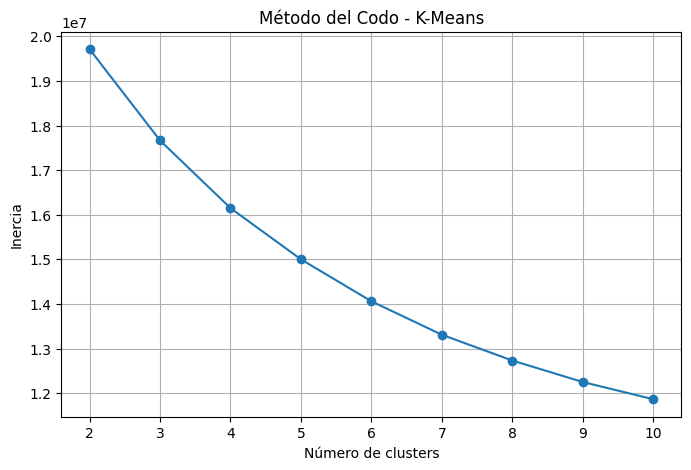

In [8]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Método del Codo - K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

7.- COEFICIENTE DE SILHOUETTE

Mide qué tan bien separados están los clusters.

Valor cercano a 1 = mejor agrupación.

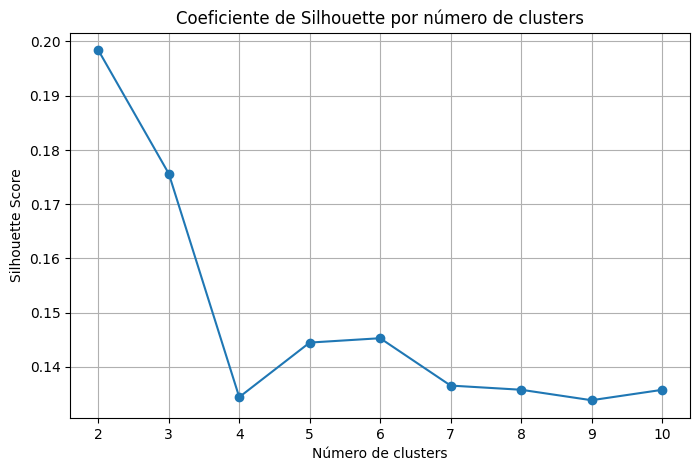

Mejor número de clusters según Silhouette: 2
Mejor Silhouette Score: 0.1984


In [9]:
silhouettes = []

# Usamos una muestra para que Colab no se ponga dramático como novela turca
X_sample = X_scaled

if len(X_scaled) > 50000:
    np.random.seed(42)
    indices = np.random.choice(len(X_scaled), 50000, replace=False)
    X_sample = X_scaled[indices]

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouettes.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouettes, marker='o')
plt.title("Coeficiente de Silhouette por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

mejor_k = K_range[np.argmax(silhouettes)]
print("Mejor número de clusters según Silhouette:", mejor_k)
print("Mejor Silhouette Score:", round(max(silhouettes), 4))

8.- Entrenar modelo Final K-MEANS

In [10]:

k_final = mejor_k

inicio = time.time()

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

fin = time.time()
tiempo_ejecucion = fin - inicio

df_resultado = df_cluster.copy()
df_resultado['cluster'] = clusters

print("Modelo K-Means entrenado correctamente.")
print("Tiempo de ejecución:", round(tiempo_ejecucion, 4), "segundos")
df_resultado.head()

Modelo K-Means entrenado correctamente.
Tiempo de ejecución: 12.1881 segundos


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode,cluster
0,0.368,0.694,0.391,0.704000,0.000007,0.0550,0.0600,168.115,-6.141,186964,1,0
1,0.731,0.685,0.811,0.122000,0.000000,0.3170,0.0572,123.010,-5.087,213645,1,1
2,0.436,0.723,0.235,0.000094,0.000088,0.0929,0.0301,92.855,-2.291,199032,1,1
3,0.519,0.601,0.498,0.289000,0.000000,0.1260,0.0317,157.964,-7.727,251667,0,0
4,0.747,0.507,0.438,0.200000,0.060800,0.1170,0.0358,104.978,-10.171,210373,1,0


9.- Métricas principales del algoritmo

In [11]:
silhouette_final = silhouette_score(X_sample, kmeans.predict(X_sample))

porcentaje_ruido = 0
# En K-Means no existe ruido como en DBSCAN.
# Todas las canciones pertenecen obligatoriamente a un cluster.

metricas = pd.DataFrame({
    "Métrica": [
        "Algoritmo",
        "Coeficiente de Silhouette",
        "Número de clusters",
        "Porcentaje de ruido",
        "Tiempo de ejecución (seg)",
        "Ventaja principal"
    ],
    "Resultado": [
        "K-Means",
        round(silhouette_final, 4),
        k_final,
        str(porcentaje_ruido) + "%",
        round(tiempo_ejecucion, 4),
        "Rápido, simple y útil para encontrar grupos musicales similares"
    ]
})

metricas

,Métrica,Resultado
0,Algoritmo,K-Means
1,Coeficiente de Silhouette,0.2006
2,Número de clusters,2
3,Porcentaje de ruido,0%
4,Tiempo de ejecución (seg),12.1881
5,Ventaja principal,"Rápido, simple y útil para encontrar grupos mu..."


10.- Cantidad de cansiones por cluster

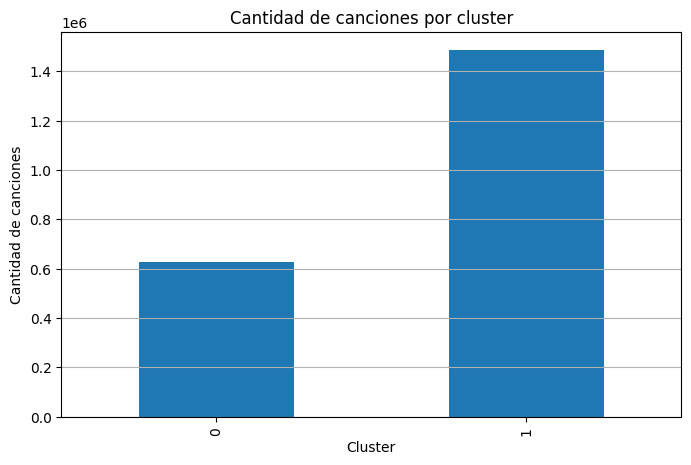

,count
cluster,
0,625396
1,1484890


In [12]:
conteo_clusters = df_resultado['cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))
conteo_clusters.plot(kind='bar')
plt.title("Cantidad de canciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de canciones")
plt.grid(axis='y')
plt.show()

conteo_clusters